 # SPAM SMS DETECTION MODEL

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

In [2]:
# Load the Data-Set
df = pd.read_csv("/Users/dineshkqryadav97gmail.com/Downloads/spam.csv", encoding= "latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [7]:
### Rename v1 and v2 by label and messages
df = df[['v1', 'v2']]
df.columns = ['label', 'message']


In [8]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.columns

Index(['label', 'message'], dtype='object')

## Check for missing values and duplicates messages are exist or not.

In [10]:
df.isnull().sum()


label      0
message    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
# Here we got 403 duplicated messages and we'll remove that by drop_duplicates.
df = df.drop_duplicates()

In [13]:
# now check duplicates messages has been remove or not.
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(5169, 2)

## now understand about legitimate and spam sms 
### legitimate or ham means authentication,real messages
### spam means unwanted or unsolicited text messages.

In [15]:
# we try to distribute ham sms or spam sms 
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

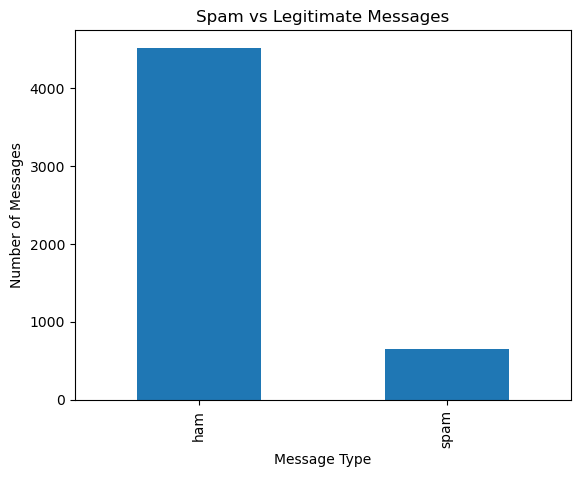

In [16]:
df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Legitimate Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

# important note : 
### here are many more legitimate messages than spam messages.
### This is called class imbalance

# Now convert labels into numbers
### Machine-learning algorithms work better when the target labels are numerical.
### ham = 0 
### spam = 1

In [17]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [18]:
df.head()


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [19]:
# Now  separate in X and Y where X will be for input and Y will be for output;
X = df['message']
y = df['label_num']

In [20]:
X.head()
y.head()

0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64

In [21]:
## A machine-learning algorithm needs numerical features.
## therefore we'll convert text into numbers using TF-IDF.
## TF-IDF
    ### Naive Bayes
    ### SVM

In [22]:
# Train Test Split + TF-IDF

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## stratify=y makes sure the training and testing sets maintain approximately the same spam/legitimate proportion.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2)
)

# Fit TF-IDF ONLY on training data


In [26]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [27]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 30960)
Testing shape: (1034, 30960)


In [28]:
# Look at the TF-IDF vocabulary

print(tfidf.get_feature_names_out()[:50])

['00' '00 easter' '00 sub' '00 subs' '000' '000 bonus' '000 cash'
 '000 homeowners' '000 pounds' '000 price' '000 prize' '000 xmas' '000pes'
 '000pes 48' '008704050406' '008704050406 sp' '0089' '0089 digits' '0121'
 '0121 2025050' '01223585236' '01223585236 xx' '01223585334'
 '01223585334 cum' '0125698789' '0125698789 ring' '02' '02 06' '02 09'
 '02 claimcode' '02 user' '0207' '0207 083' '0207 153' '02072069400'
 '02072069400 bx' '03' '03 05' '03 2nd' '03 final' '03 marsms' '04' '0430'
 '0430 jul' '05' '05 05' '05 prize' '050703' '050703 csbcm4235wc1n3xx'
 '0578']


In [29]:
# Here we are going to train model in 3 way: Naive bayes, logistic regression, svm.

# Train Naive Bayes

In [30]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

# the model has learned patterns associated with legistimate  = 0 and spam = 1;

# Train Logistic Regression 

In [31]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

# Train SVM 

In [32]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [34]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

In [35]:
evaluate_model("Naive Bayes", y_test, nb_pred)

evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("SVM", y_test, svm_pred)


Naive Bayes
----------------------------------------
Accuracy : 0.9535783365570599
Precision: 1.0
Recall   : 0.6335877862595419
F1 Score : 0.7757009345794392

Logistic Regression
----------------------------------------
Accuracy : 0.9458413926499033
Precision: 0.987012987012987
Recall   : 0.5801526717557252
F1 Score : 0.7307692307692307

SVM
----------------------------------------
Accuracy : 0.9816247582205029
Precision: 0.9827586206896551
Recall   : 0.8702290076335878
F1 Score : 0.9230769230769231


# Classification Report 

In [36]:
print("NAIVE BAYES")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Legitimate", "Spam"]
))

print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Legitimate", "Spam"]
))

print("SVM")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Legitimate", "Spam"]
))

NAIVE BAYES
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.87      1034
weighted avg       0.96      0.95      0.95      1034

LOGISTIC REGRESSION
              precision    recall  f1-score   support

  Legitimate       0.94      1.00      0.97       903
        Spam       0.99      0.58      0.73       131

    accuracy                           0.95      1034
   macro avg       0.96      0.79      0.85      1034
weighted avg       0.95      0.95      0.94      1034

SVM
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99       903
        Spam       0.98      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.96      1034
weighted avg       0.98      0.98     

# Confusion matrix

In [37]:
cm = confusion_matrix(y_test, svm_pred)

print(cm)

[[901   2]
 [ 17 114]]


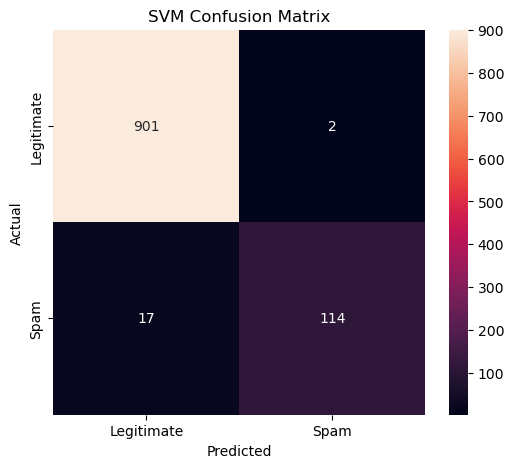

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Legitimate', 'Spam'],
    yticklabels=['Legitimate', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

## compare all three model 

In [39]:
results = {
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.953578,1.000000,0.633588,0.775701
1,Logistic Regression,0.945841,0.987013,0.580153,0.730769
2,SVM,0.981625,0.982759,0.870229,0.923077


In [40]:
### here svm model is the best providing output 98 % ACCURACY  as compare to other two models so we'll go with it .

In [41]:
best_model = svm_model

In [42]:
def predict_sms(message):
    message_tfidf = tfidf.transform([message])
    
    prediction = best_model.predict(message_tfidf)[0]
    
    if prediction == 1:
        print("SPAM MESSAGE")
    else:
        print("LEGITIMATE MESSAGE")

In [43]:
# Now try to test model 

In [44]:
sms = "Congratulations! You have won a free iPhone. Click here to claim your prize!"

print(predict_sms(sms))

SPAM MESSAGE
None


In [45]:
sms = "Hey, are you coming to college tomorrow?"

print(predict_sms(sms))

LEGITIMATE MESSAGE
None


In [46]:
predict_sms(
    "Congratulations! You have won a free lottery prize!"
)

SPAM MESSAGE


In [47]:
# Test several real-world messages together.
test_messages = [
    "Congratulations! You won a free lottery prize!",
    "Hey, what time are we meeting today?",
    "URGENT! You have won $1000. Click this link now!",
    "Can you send me the notes from today's class?",
    "Claim your FREE reward now!",
    "Mom asked you to call her."
]

for message in test_messages:
    print("\nSMS:", message)
    print("Prediction:", predict_sms(message))


SMS: Congratulations! You won a free lottery prize!
SPAM MESSAGE
Prediction: None

SMS: Hey, what time are we meeting today?
LEGITIMATE MESSAGE
Prediction: None

SMS: URGENT! You have won $1000. Click this link now!
SPAM MESSAGE
Prediction: None

SMS: Can you send me the notes from today's class?
LEGITIMATE MESSAGE
Prediction: None

SMS: Claim your FREE reward now!
SPAM MESSAGE
Prediction: None

SMS: Mom asked you to call her.
LEGITIMATE MESSAGE
Prediction: None


# Save the trained Model.

In [48]:
import joblib

joblib.dump(best_model, "spam_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [49]:
import joblib

loaded_model = joblib.load("spam_classifier.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

# TEST THE MODEL MULTIPLE TIMES :

In [50]:
predict_sms(
    "Congratulations! You have won a free lottery prize!"
)

SPAM MESSAGE


In [51]:
predict_sms("hey! how are you buddy")

LEGITIMATE MESSAGE


In [52]:
predict_sms("Congratulations! You have won a free lottery prize!")

SPAM MESSAGE


In [53]:
predict_sms(" congrats! you won a free lottry prize tv via kukufm")

SPAM MESSAGE


In [54]:
predict_sms(" Radhe Radhe ")

LEGITIMATE MESSAGE


# Conclusion

## The SMS Spam Detection project successfully classifies SMS messages as **Spam** or **Legitimate** using Natural Language Processing and machine learning. TF-IDF was used to convert text messages into numerical features, and three classification algorithms—Naive Bayes, Logistic Regression, and Support Vector Machine—were evaluated.

## Among the tested models, **SVM achieved the best performance with 98.16% accuracy and a 92.31% F1-score**. Therefore, SVM was selected as the final classification model. 

## Overall, the project demonstrates that **TF-IDF combined with SVM is an effective approach for SMS spam detection** and can help users identify unwanted or potentially fraudulent messages automatically.